In [13]:
# Import 
import torch
from torch.utils.data import DataLoader, random_split
import torch.nn.functional as F
from torch import nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from numpy import linalg as LA

from unet import UNet
from data import CarvanaDataset
from unet.utils import dice_coefficient


In [ ]:
# Load Data
train_dataset = CarvanaDataset("/app/UNet/data/datasets/carvana")

generator = torch.Generator().manual_seed(25)
train_dataset, test_dataset = random_split(train_dataset, [0.8, 0.2], generator=generator)
test_dataset, val_dataset = random_split(test_dataset, [0.5, 0.5], generator=generator)

device = "cuda" if torch.cuda.is_available() else "cpu"

if device == "cuda":
    num_workers = torch.cuda.device_count() * 4

In [ ]:
# Hyperparameters
LEARNING_RATE = 3e-4
BATCH_SIZE = 8

# DataLoaders, Model, Optimizer, Loss
train_dataloader = DataLoader(dataset=train_dataset,
                              num_workers=num_workers, pin_memory=False,
                              batch_size=BATCH_SIZE,
                              shuffle=True)
val_dataloader = DataLoader(dataset=val_dataset,
                            num_workers=num_workers, pin_memory=False,
                            batch_size=BATCH_SIZE,
                            shuffle=True)

test_dataloader = DataLoader(dataset=test_dataset,
                            num_workers=num_workers, pin_memory=False,
                            batch_size=BATCH_SIZE,
                            shuffle=True)

model = UNet(in_channels=3, num_classes=1)
model = nn.DataParallel(model)
model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCEWithLogitsLoss()

torch.cuda.empty_cache()

In [ ]:
# Training
EPOCHS = 5

train_losses = []
train_dcs = []
val_losses = []
val_dcs = []

for epoch in tqdm(range(EPOCHS)):
    model.train()
    train_running_loss = 0
    train_running_dc = 0
    
    for idx, img_mask in enumerate(tqdm(train_dataloader, position=0, leave=True)):
        img = img_mask[0].float().to(device)
        mask = img_mask[1].float().to(device)
        
        y_pred = model(img)
        optimizer.zero_grad()
        
        dc = dice_coefficient(y_pred, mask)
        loss = criterion(y_pred, mask)
        
        train_running_loss += loss.item()
        train_running_dc += dc.item()

        loss.backward()
        optimizer.step()

    train_loss = train_running_loss / (idx + 1)
    train_dc = train_running_dc / (idx + 1)
    
    train_losses.append(train_loss)
    train_dcs.append(train_dc)

    model.eval()
    val_running_loss = 0
    val_running_dc = 0
    
    with torch.no_grad():
        for idx, img_mask in enumerate(tqdm(val_dataloader, position=0, leave=True)):
            img = img_mask[0].float().to(device)
            mask = img_mask[1].float().to(device)

            y_pred = model(img)
            loss = criterion(y_pred, mask)
            dc = dice_coefficient(y_pred, mask)
            
            val_running_loss += loss.item()
            val_running_dc += dc.item()

        val_loss = val_running_loss / (idx + 1)
        val_dc = val_running_dc / (idx + 1)
    
    val_losses.append(val_loss)
    val_dcs.append(val_dc)

    print("-" * 30)
    print(f"Training Loss EPOCH {epoch + 1}: {train_loss:.4f}")
    print(f"Training DICE EPOCH {epoch + 1}: {train_dc:.4f}")
    print("\n")
    print(f"Validation Loss EPOCH {epoch + 1}: {val_loss:.4f}")
    print(f"Validation DICE EPOCH {epoch + 1}: {val_dc:.4f}")
    print("-" * 30)

# Saving the model
torch.save(model.state_dict(), 'unet_checkpoint.pth')


 20%|██        | 1/5 [01:00<04:03, 60.88s/it]

------------------------------
Training Loss EPOCH 1: 0.1906
Training DICE EPOCH 1: 0.7806


Validation Loss EPOCH 1: 0.0710
Validation DICE EPOCH 1: 0.9337
------------------------------


 40%|████      | 2/5 [01:56<02:54, 58.06s/it]

------------------------------
Training Loss EPOCH 2: 0.0626
Training DICE EPOCH 2: 0.9422


Validation Loss EPOCH 2: 0.0308
Validation DICE EPOCH 2: 0.9708
------------------------------


 60%|██████    | 3/5 [02:52<01:53, 56.79s/it]

------------------------------
Training Loss EPOCH 3: 0.0289
Training DICE EPOCH 3: 0.9731


Validation Loss EPOCH 3: 0.0214
Validation DICE EPOCH 3: 0.9800
------------------------------


 80%|████████  | 4/5 [03:46<00:55, 55.83s/it]

------------------------------
Training Loss EPOCH 4: 0.0202
Training DICE EPOCH 4: 0.9813


Validation Loss EPOCH 4: 0.0172
Validation DICE EPOCH 4: 0.9842
------------------------------


100%|██████████| 5/5 [04:41<00:00, 56.35s/it]


------------------------------
Training Loss EPOCH 5: 0.0148
Training DICE EPOCH 5: 0.9864


Validation Loss EPOCH 5: 0.0130
Validation DICE EPOCH 5: 0.9879
------------------------------


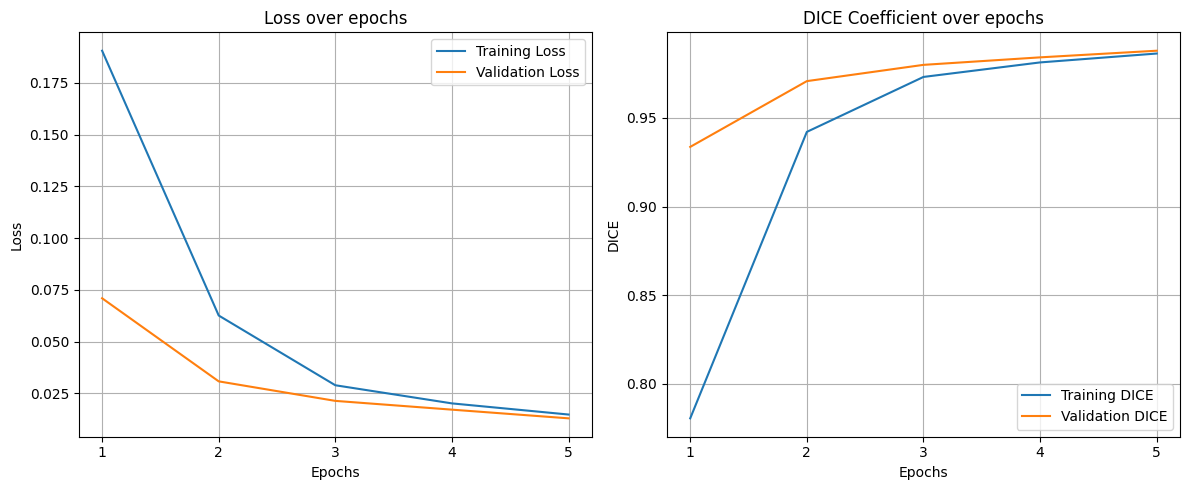

In [ ]:
# Plotting the results
epochs_list = list(range(1, EPOCHS + 1))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_list, train_losses, label='Training Loss')
plt.plot(epochs_list, val_losses, label='Validation Loss')
plt.xticks(ticks=list(range(1, EPOCHS + 1, 1))) 
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.tight_layout()

plt.legend()


plt.subplot(1, 2, 2)
plt.plot(epochs_list, train_dcs, label='Training DICE')
plt.plot(epochs_list, val_dcs, label='Validation DICE')
plt.xticks(ticks=list(range(1, EPOCHS + 1, 1)))  
plt.title('DICE Coefficient over epochs')
plt.xlabel('Epochs')
plt.ylabel('DICE')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
# Testing the model
model_pth = 'unet_checkpoint.pth'
trained_model = UNet(in_channels=3, num_classes=1).to(device)

# Load the state dict and handle DataParallel prefix
state_dict = torch.load(model_pth, map_location=torch.device(device))

if any(key.startswith('module.') for key in state_dict.keys()):
    state_dict = {key.replace('module.', ''): value for key, value in state_dict.items()}

trained_model.load_state_dict(state_dict)
trained_model.eval()

UNet(
  (down_conv1): DownSample(
    (conv): DoubleConv(
      (conv_op): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
      )
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (down_conv2): DownSample(
    (conv): DoubleConv(
      (conv_op): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): ReLU(inplace=True)
      )
    )
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (down_conv3): DownSample(
    (conv): DoubleConv(
      (conv_op): Sequential(
        (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): R

In [ ]:
# Evaluate on test set
test_running_loss = 0
test_running_dc = 0

with torch.no_grad():
    for idx, img_mask in enumerate(tqdm(test_dataloader, position=0, leave=True)):
        img = img_mask[0].float().to(device)
        mask = img_mask[1].float().to(device)

        y_pred = trained_model(img)
        loss = criterion(y_pred, mask)
        dc = dice_coefficient(y_pred, mask)

        test_running_loss += loss.item()
        test_running_dc += dc.item()

    test_loss = test_running_loss / (idx + 1)
    test_dc = test_running_dc / (idx + 1)
print("Test Results")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test DICE: {test_dc:.4f}")


100%|██████████| 64/64 [00:04<00:00, 13.35it/s]

Test Results
Test Loss: 0.0131
Test DICE: 0.9878
